In [ ]:
import os
import re
from io import StringIO
from pathlib import Path
import gc 

import anndata as ad
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import math

import cell2location
from cell2location.utils import select_slide
from cell2location.plt import plot_spatial
from cell2location.utils.filtering import filter_genes
from cell2location.models import RegressionModel, Cell2location
import torch 

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Set up reference signatures
- get cell2fate reference
- remember: you selected sites/sections based on dominant clones (use snRNA-seq clone information)
- load ref sig best suited to that clone + sites and map it to sections best suited to those clones
- focused on AT15 in the paper

In [ ]:
results_folder = '../data/trajectories/'
run_name = os.path.join(results_folder, "cell2location_map")
clone = 'at15_4'
sections = ['AT15-BRA-4-FO-C2-S27']

# Load cell2location

In [ ]:
sample_directory = '../../../data/cytassist/phase_1'
samples = [folder for folder, subs, files in os.walk(sample_directory)\
    if folder.endswith('GRCh38-2020-A')]
samples = [i for i in samples if 'AT20' not in i]
samples = [i for i in samples if 'unknown' not in i]

sample_list_cytassist = []
for path in samples:
    site_id = re.sub('^.*/(.*?)/spac.*$', '\\1', path)
    donor_id = re.sub('^.*phase_1/(.*?)/.*$', '\\1', path)
    sample = re.sub('^.*/', '', path)
    

    
    sample_list_cytassist.append(pd.DataFrame({'sample':sample,
                                     'site_id':site_id,
                                     'sample_name':site_id, # to make downstream analyses simple
                                     'donor_id':donor_id,
                                     'paths':path}, index=[0]))
sample_list_cytassist = pd.concat(sample_list_cytassist, ignore_index=True)
sample_list = sample_list_cytassist[~sample_list_cytassist['paths'].str.contains('delete')]\
    .reset_index(drop=True)

In [ ]:
adatas = {}
for section in sections:
    row = sample_list[sample_list['sample_name']==section].iloc[0]
            
    sample_name = row['sample_name']
    sample = row['sample']
    site_id = row['site_id']
    path = row['paths']

    # Pre-processing steps
    adata = sq.read.visium(path, library_id=sample_name)
    adata.var = (adata.var.reset_index().
                    rename(columns={"index": "SYMBOL", "gene_ids": "ENSEMBL"}).
                    set_index("ENSEMBL"))
    adata.obs['sample'] = sample
    adata.obs['sample_name'] = sample_name
    adata.var['mt'] = [gene.startswith('MT-') for gene in adata.var['SYMBOL']]
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
    adata.uns["sample_name"] = sample_name
    adatas[section] = adata

/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
adata_vis = ad.concat(adatas, label="sample", merge="same", 
                      uns_merge="unique", index_unique="_")
        
adata_vis.obsm['mt'] = adata_vis.X[:, adata_vis.var['mt'].to_numpy()]
adata_vis = adata_vis[:, ~adata_vis.var['mt'].to_numpy()]
adata_vis.var = adata_vis.var.reset_index()
adata_vis.var_names = adata_vis.var['SYMBOL']
adata_vis = adata_vis[: , ~adata_vis.var['SYMBOL'].duplicated(keep='first')]

# Remove non-malignant spots
- Load spacetree data and remove spots not associated with clone

In [ ]:
spacetree_dir = '../../../data/GBM_LEAP_annotations/spacetree_new/'
spacetree_files = os.listdir(spacetree_dir)
spacetree_files = [i for i in spacetree_files if re.sub('^.*_count_', '', row['sample']) in i]

spacetree_df = []
for file in spacetree_files:
    adata_obs = sc.read_h5ad(spacetree_dir+file).obs
    adata_obs['barcodes'] = [re.sub('^.*_', '', i) for i in adata_obs.index]
    adata_obs['spaceranger_id']  = [re.sub('A_.*$', 'A', i) for i in adata_obs.index]
    adata_obs.index = adata_obs['barcodes'].astype(str)+'_'+adata_obs['spaceranger_id'].astype(str)

    spacetree_df.append(adata_obs)
spacetree_df = pd.concat(spacetree_df)

all_clones = [str(i) for i in range(19) if str(i) in spacetree_df.columns]+['diploid']
spacetree_df = spacetree_df[all_clones]

# AT15_4 greater than median; diploid less 50% of abundance
spacetree_df['malignant_spots'] = (spacetree_df['diploid']<0.5)
spacetree_df['barcode'] = [re.sub('_space.*$', '', i) for i in spacetree_df.index]
spacetree_df['index_vis'] = spacetree_df['barcode'].astype(str)+'_'+row['sample_name']
spacetree_df = spacetree_df[spacetree_df['malignant_spots']==True]

In [ ]:
adata_vis = adata_vis[adata_vis.obs.index.isin(spacetree_df['index_vis'])]

/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c


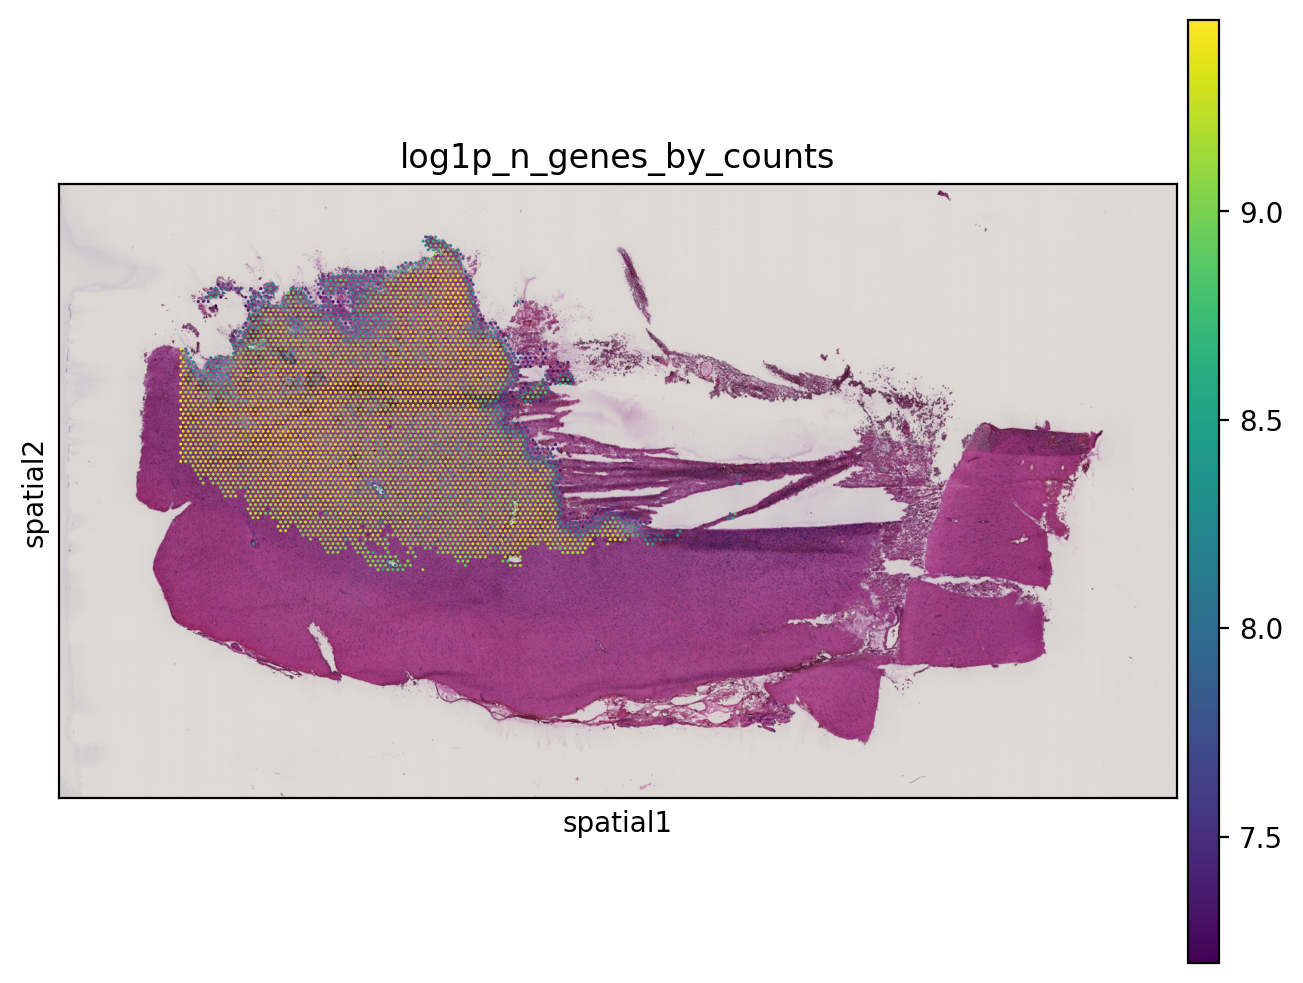

In [ ]:
sq.pl.spatial_scatter(
    adata_vis,
    color="log1p_n_genes_by_counts"
)

# Run cell2location

Load ref adata... at15_4
Setup adatas... at15_4


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Anndata setup with scvi-tools version 1.1.2.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:72: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
You are using a CUDA device ('NVIDIA H100 80GB HBM3') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/software/cellgen/team283/gd11/envs/cell2loc_env/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:293: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set 

Epoch 9000/9000: 100%|████████████████████████████████████████████████████████| 9000/9000 [23:03<00:00,  7.03it/s, v_num=1, elbo_train=1.55e+7]

`Trainer.fit` stopped: `max_epochs=9000` reached.


Epoch 9000/9000: 100%|████████████████████████████████████████████████████████| 9000/9000 [23:03<00:00,  6.50it/s, v_num=1, elbo_train=1.55e+7]


1265

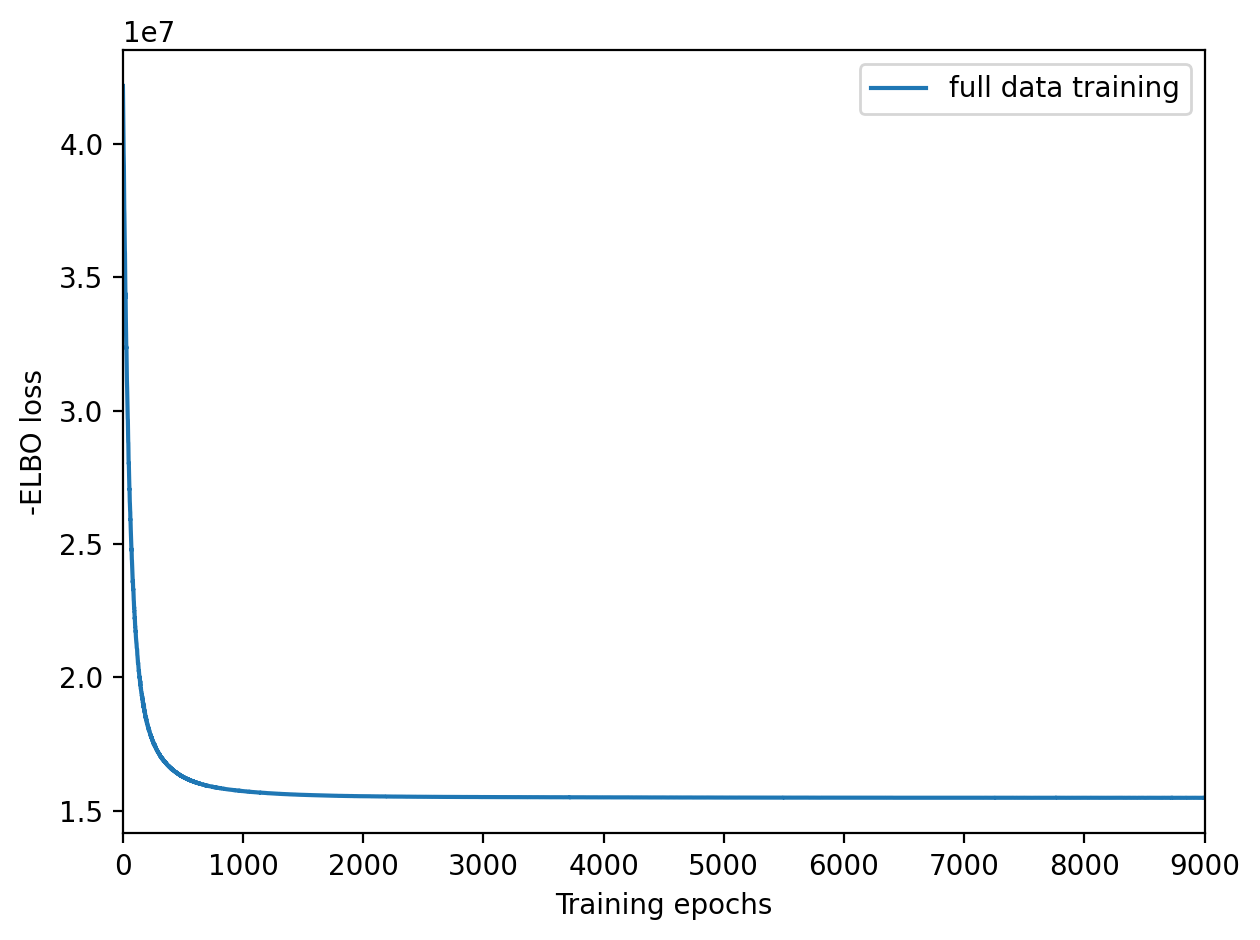

In [ ]:
print('Load ref adata... {}'.format(clone))
# Load ref sigs from previous step (per donor)
inf_aver = pd.read_csv(os.path.join(results_folder,clone+'modules.csv'), index_col=0)
ref_var_names = inf_aver.index.tolist()

print('Setup adatas... {}'.format(clone))
# Set up signatures    
intersect = adata_vis.var_names.intersection(ref_var_names)

adata_vis = adata_vis[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :]

# set up model
# might be good to assess parameters here in a few demo runs
Cell2location.setup_anndata(adata_vis, batch_key="sample")
mod = cell2location.models.Cell2location(
    adata_vis, cell_state_df=inf_aver,
    N_cells_per_location=30,
    detection_alpha=200)
mod.view_anndata_setup(adata_vis)
    
# train model
# added batch size arg; necessary for cytassist or large batches
mod.train(max_epochs=9000,
          batch_size=math.ceil((1/4) * adata_vis.n_obs),
          train_size=1)

mod.plot_history()
plt.legend(labels=['full data training'])
plt.savefig('epoch_QC_batch{}'.format(clone))

# Again, memory issues means this step is potentially problematic; should test
# 'use_quantiles = True' exports less information but won't cause a crash 
# and should still provide interpretable abundance estimates
mod.save('{}/{}'.format(run_name, clone), overwrite=True)
adata_vis = mod.export_posterior(
            adata_vis, use_quantiles = True)
adata_vis.write_h5ad(os.path.join(run_name, "sp_batch{}.h5ad".format(clone)))

# Important to note: delete model object as it occupies gpu mem
del(mod)
torch.cuda.empty_cache()
gc.collect()